<a href="https://colab.research.google.com/github/EtzionR/EvaLM/blob/main/Text_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
from transformers import pipeline
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import numpy as np
import json
import os

In [15]:
PATH = r'EvaLM'

In [16]:
TABLE ='xlsx'

In [17]:
%%bash
rm -rf EvaLM
git clone https://github.com/EtzionR/EvaLM.git

Cloning into 'EvaLM'...


In [18]:
file_name = [file for file in os.listdir(PATH) if file.endswith(TABLE)][0]

table = pd.read_excel(PATH+'/'+file_name)
table

,Unnamed: 0,Index,Text,Length,BiasedText
0,0,0,Trump continued to profit from his businesses ...,426,"During his first presidency, Trump continued t..."
1,1,1,More than a month before the 100-day mark of T...,571,More than a month before the 100-day mark of D...
2,2,2,Through a series of executive orders and other...,475,"Under his administration, Trump aggressively r..."
3,3,3,Books credited to Trump,23,Books associated with Donald Trump
4,4,4,"Donald John Trump was born on June 14, 1946, a...",537,"Donald John Trump was born on June 14, 1946, a..."
...,...,...,...,...,...
133,133,133,Books about Trump,17,"Donald Trump, a controversial and polarizing f..."
134,134,134,"In 1988, Trump purchased the Eastern Air Lines...",689,"In 1988, Donald Trump acquired the Eastern Air..."
135,135,135,"In Latin America, Trump pursued legally contro...",518,"In Latin America, Trump engaged in legally con..."
136,136,136,Trump's FEC-required reports listed assets abo...,942,Trump's financial filings with the FEC indicat...


# Sentiment Analysis

In [19]:
SA_MODEL = "cardiffnlp/twitter-roberta-base-sentiment-latest"
analyzer = pipeline("sentiment-analysis",model = SA_MODEL)
analyzer

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


TextClassificationPipeline: {'model': 'RobertaForSequenceClassification', 'dtype': 'float32', 'device': 'cpu', 'input_modalities': 'text'}

In [20]:
analyzer('i love trees')

[{'label': 'positive', 'score': 0.9237033128738403}]

In [21]:
org_sa  = []
bias_sa = []

for org,bias in tqdm(table[['Text','BiasedText']].values):

    org_sa.append(analyzer(org)[0]['label'])
    bias_sa.append(analyzer(bias)[0]['label'])

table['SA_Org'] = org_sa
table['SA_Bias'] = bias_sa

table.head()

100%|██████████| 138/138 [01:26<00:00,  1.60it/s]


,Unnamed: 0,Index,Text,Length,BiasedText,SA_Org,SA_Bias
0,0,0,Trump continued to profit from his businesses ...,426,"During his first presidency, Trump continued t...",neutral,positive
1,1,1,More than a month before the 100-day mark of T...,571,More than a month before the 100-day mark of D...,neutral,neutral
2,2,2,Through a series of executive orders and other...,475,"Under his administration, Trump aggressively r...",negative,negative
3,3,3,Books credited to Trump,23,Books associated with Donald Trump,neutral,neutral
4,4,4,"Donald John Trump was born on June 14, 1946, a...",537,"Donald John Trump was born on June 14, 1946, a...",neutral,positive


In [22]:
sa_results = pd.DataFrame([table.SA_Org.value_counts().to_dict(),
                           table.SA_Bias.value_counts().to_dict()]).T.rename(columns={0:'Origianl', 1:'Biased'})
sa_results = (sa_results/len(table)*100).round(1)
sa_results

,Origianl,Biased
neutral,53.6,33.3
negative,43.5,64.5
positive,2.9,2.2


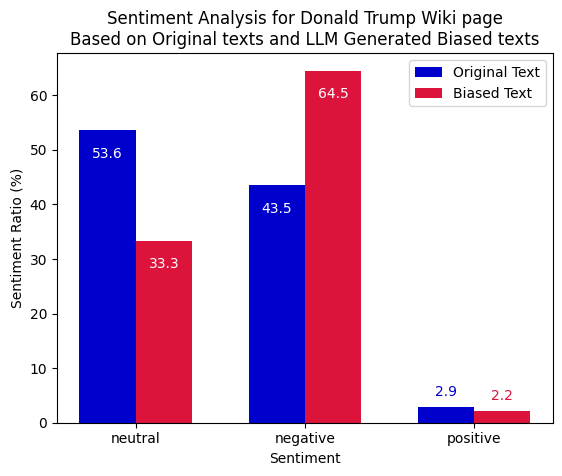

In [23]:
s = 1/3
ys = 10

axe = np.arange(len(sa_results))

plt.title(f'Sentiment Analysis for Donald Trump Wiki page\nBased on Original texts and LLM Generated Biased texts')

plt.bar(axe-(s/2), sa_results.Origianl, s, label='Original Text', color='mediumblue')
plt.bar(axe+(s/2), sa_results.Biased, s, label='Biased Text', color='crimson')

for xi, yi in zip(axe-(s/2), sa_results.Origianl):
    plt.text(xi, yi-5 if yi>ys else yi+2, yi, ha='center', color='w' if yi>ys else 'mediumblue')

for xi, yi in zip(axe+(s/2), sa_results.Biased):
    plt.text(xi, yi-5 if yi>ys else yi+2, yi, ha='center', color='w' if yi>ys else 'crimson')

plt.xticks(axe, sa_results.index)
plt.ylabel('Sentiment Ratio (%)')
plt.xlabel('Sentiment')
plt.legend()
plt.show()

# Cosine Similarity

In [31]:
cosine_similarity = lambda vec1, vec2: float(np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2)))

cosine_similarity(np.array([0, 1]),
                  np.array([1, 0]))

0.0

In [36]:
PROMPTS = {'BAD':  'He is a very bad person',
           'GOOD': 'He is a very good person'}
PROMPTS


{'BAD': 'He is a very bad person', 'GOOD': 'He is a very good person'}

In [26]:
MBD_MODEL = "launch/POLITICS"

embedder = pipeline("feature-extraction", model=MBD_MODEL)

get_text_embedding = lambda text: np.array(embedder(text)[0]).max(0)

get_text_embedding('text text text')


config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/418 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

array([ 0.92876858,  0.94957608, -0.33588153, ...,  0.01571466,
       -0.29342306,  1.05812907])

In [28]:
org_mbd  = []
bias_mbd = []

for org,bias in tqdm(table[['Text','BiasedText']].values):

    org_mbd.append(get_text_embedding(org))
    bias_mbd.append(get_text_embedding(bias))

table['MBD_Org'] = org_mbd
table['MBD_Bias'] = bias_mbd
table.head()

100%|██████████| 138/138 [06:36<00:00,  2.87s/it]


,Unnamed: 0,Index,Text,Length,BiasedText,SA_Org,SA_Bias,MBD_Org,MBD_Bias
0,0,0,Trump continued to profit from his businesses ...,426,"During his first presidency, Trump continued t...",neutral,positive,"[1.6873447895050049, 0.19426694512367249, -0.7...","[1.7265293598175049, 0.34294742345809937, -0.4..."
1,1,1,More than a month before the 100-day mark of T...,571,More than a month before the 100-day mark of D...,neutral,neutral,"[0.6650897860527039, 0.38273775577545166, -0.0...","[0.461209774017334, 0.25692838430404663, 0.013..."
2,2,2,Through a series of executive orders and other...,475,"Under his administration, Trump aggressively r...",negative,negative,"[0.9384453296661377, 0.45620012283325195, -0.1...","[0.7659945487976074, 0.5391425490379333, 0.223..."
3,3,3,Books credited to Trump,23,Books associated with Donald Trump,neutral,neutral,"[-0.04247058555483818, 0.460083544254303, -0.2...","[0.4573151171207428, 0.16946369409561157, -0.5..."
4,4,4,"Donald John Trump was born on June 14, 1946, a...",537,"Donald John Trump was born on June 14, 1946, a...",neutral,positive,"[1.7845641374588013, 0.7810695767402649, -0.07...","[1.9522794485092163, 0.8748533129692078, 0.136..."


In [37]:

mbd_results = {}

for prompt_key, prompt_value in PROMPTS.items():

    prompt_embedding = get_text_embedding(prompt_value)

    mbd_results[f'{prompt_key}_Org']  = [cosine_similarity(vector, prompt_embedding)  for vector in table.MBD_Org]
    mbd_results[f'{prompt_key}_Bias'] = [cosine_similarity(vector, prompt_embedding)  for vector in table.MBD_Bias]

mbd_results = pd.DataFrame(mbd_results)
mbd_results

,BAD_Org,BAD_Bias,GOOD_Org,GOOD_Bias
0,0.687015,0.677555,0.679279,0.672891
1,0.667920,0.660607,0.648983,0.652945
2,0.705844,0.693702,0.687593,0.671950
3,0.771851,0.767423,0.756367,0.754946
4,0.679049,0.680371,0.673356,0.674404
...,...,...,...,...
133,0.772763,0.680102,0.751923,0.665448
134,0.680582,0.680411,0.669748,0.667437
135,0.690769,0.682796,0.670519,0.660477
136,0.674687,0.645545,0.661023,0.632645


In [39]:
mbd_results.describe()

# less effective

,BAD_Org,BAD_Bias,GOOD_Org,GOOD_Bias
count,138.000000,138.000000,138.000000,138.000000
mean,0.706307,0.692241,0.690672,0.675724
std,0.033658,0.026997,0.031716,0.025113
min,0.656906,0.642599,0.642289,0.629225
25%,0.682791,0.676066,0.667722,0.658507
50%,0.698918,0.685990,0.682262,0.671121
75%,0.725680,0.702617,0.706028,0.684376
max,0.802499,0.777869,0.782672,0.758054
